# Evaluating the Improved Model on the Full 23k Dataset

Loads `models/resnet50_stylesync_v2.pt` (trained on the balanced 1,394-row subset, 96.4% val acc on that subset) and evaluates it on the **full ~23k-row `combined_df.csv`** (filtered to the 5 subcategories, images from `data/images/processed_images/`).

**Question this notebook answers:** does a model trained on a hand-balanced subset generalize to the natural distribution of clothing items?

No training happens here — pure inference + metrics.

In [1]:
import sys, os
from pathlib import Path
sys.path.append(os.path.abspath(".."))

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
SUBCATEGORY_TO_LABEL = {
    "Tops":       0,
    "Bottomwear": 1,
    "Shoes":      2,
    "Dress":      3,
    "Outerwear":  4,
}
LABEL_TO_SUBCATEGORY = {v: k for k, v in SUBCATEGORY_TO_LABEL.items()}
CLASS_NAMES = [LABEL_TO_SUBCATEGORY[i] for i in range(len(SUBCATEGORY_TO_LABEL))]
NUM_CLASSES = len(SUBCATEGORY_TO_LABEL)

In [3]:
IMG_DIR = Path("../data/images/person_aware_cropped")

df = pd.read_csv("../data/combined_df.csv")
df = df[df["subCategory"].isin(SUBCATEGORY_TO_LABEL)].reset_index(drop=True)
df = df[df["id"].apply(lambda x: (IMG_DIR / f"{x}.jpg").exists())].reset_index(drop=True)

print(f"Total samples: {len(df):,}")
print("\nDistribution:")
print(df["subCategory"].value_counts())

Total samples: 23,388

Distribution:
subCategory
Tops          12773
Shoes          7321
Bottomwear     2536
Dress           480
Outerwear       278
Name: count, dtype: int64


In [4]:
IMAGE_SIZE = 224
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class WardrobeDataset(Dataset):
    def __init__(self, df, image_dir, transform):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = self.image_dir / f"{row['id']}.jpg"
        label = SUBCATEGORY_TO_LABEL[row["subCategory"]]
        img   = Image.open(path).convert("RGB")
        return self.transform(img), label

dataset = WardrobeDataset(df, IMG_DIR, transform=eval_transform)
loader  = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

### Load the trained model

Same architecture as `model_training_improved.ipynb` — ResNet50 with `layer4` unfrozen and a 5-class FC head.

In [5]:
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = "../models/resnet50_stylesync_v2.pt"
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model = model.to(device).eval()

print(f"Loaded {ckpt_path} onto {device}")

Loaded ../models/resnet50_stylesync_v2.pt onto mps


### Run inference on all 23k images

In [6]:
all_logits, all_labels = [], []
with torch.no_grad():
    for i, (images, labels) in enumerate(loader, start=1):
        images = images.to(device)
        logits = model(images).cpu().numpy()
        all_logits.append(logits)
        all_labels.extend(labels.numpy())
        if i % 50 == 0 or i == len(loader):
            print(f"batch {i}/{len(loader)}")

all_logits = np.concatenate(all_logits, axis=0)   # shape (N, 5)
all_labels = np.array(all_labels)
all_preds  = all_logits.argmax(axis=1)

overall_acc = (all_preds == all_labels).mean()
print(f"\nOverall accuracy on full dataset: {overall_acc:.4f}  ({(all_preds == all_labels).sum():,}/{len(all_labels):,})")

batch 50/366


batch 100/366


batch 150/366


batch 200/366


batch 250/366


batch 300/366


batch 350/366


batch 366/366

Overall accuracy on full dataset: 0.9458  (22,120/23,388)


### Confusion matrix

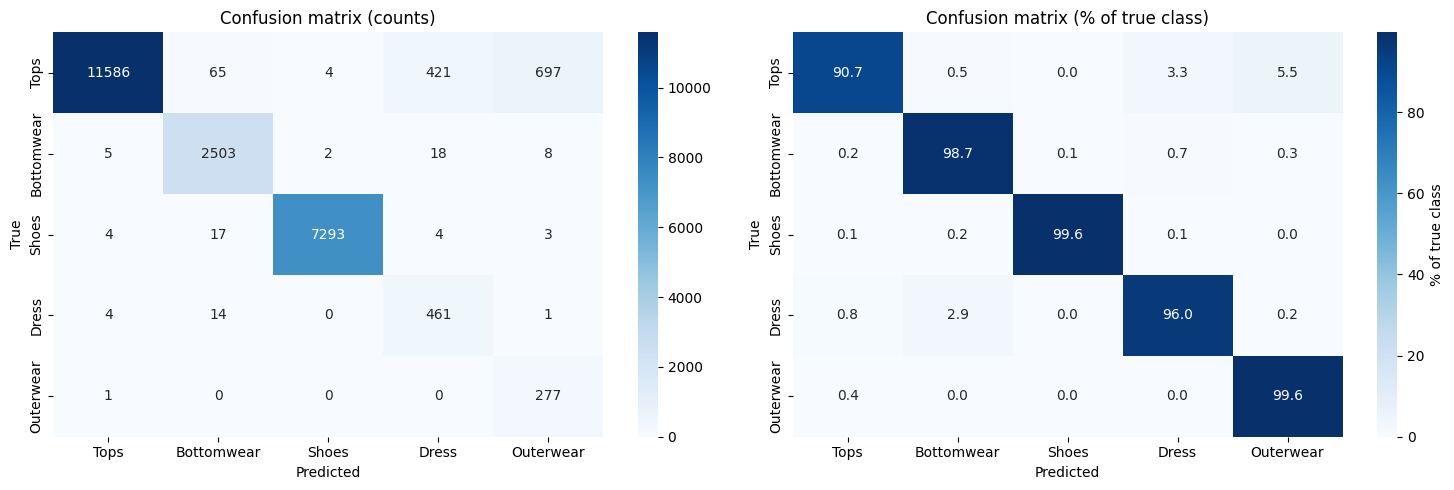

In [7]:
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
            cbar_kws={"label": "% of true class"})
axes[1].set_title("Confusion matrix (% of true class)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout(); plt.show()

### Per-class precision / recall / F1

**Macro-F1** is the unweighted average across classes. If it's much lower than overall accuracy, the model is doing well on common classes but failing on rare ones. **Weighted-F1** matches accuracy more closely (frequency-weighted).

In [8]:
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

              precision    recall  f1-score   support

        Tops     0.9988    0.9071    0.9507     12773
  Bottomwear     0.9631    0.9870    0.9749      2536
       Shoes     0.9992    0.9962    0.9977      7321
       Dress     0.5100    0.9604    0.6662       480
   Outerwear     0.2809    0.9964    0.4383       278

    accuracy                         0.9458     23388
   macro avg     0.7504    0.9694    0.8056     23388
weighted avg     0.9765    0.9458    0.9561     23388



### How to read the results

- **Overall accuracy** ≈ how often the model was right across all 23k items.
- **Per-class recall** (in the classification report) is the most diagnostic number — it's the % of *true* items in each class that were correctly identified. Watch the rare classes (Outerwear, Dress).
- **Confusion matrix (right panel)** shows where errors go: e.g. Outerwear getting confused with Tops would be a row 4 → column 0 hot spot.

**Decision criterion for whether to retrain on the full dataset:**
- If macro-F1 ≥ ~0.85 and per-class recall is decent across all 5 classes → the balanced-trained model generalizes fine. Ship it.
- If macro-F1 is much lower than accuracy, or any class has recall < 0.7 → retrain on the full dataset with class-weighted loss for a better model.

## Prior correction (no retraining)

The model was trained on a balanced subset where each class was ~20% of the data, so it learned a uniform class prior. On the full dataset Tops are 55% and Outerwear is 1%, so when the model says "Outerwear" it's still implicitly assuming Outerwear is 20% likely a priori — over-predicting rare classes.

Bayes fix: shift each logit by `log(deploy_prior / train_prior)`. No retraining needed. This corrects the prior mismatch but doesn't change what the model has learned about the visual features.

In [9]:
# Train prior — from the balanced 1394-row training set
balanced_df = pd.read_csv("../data/balanced_df.csv")
train_freq  = balanced_df["subCategory"].value_counts().reindex(CLASS_NAMES).fillna(0).values
train_prior = train_freq / train_freq.sum()

# Deploy prior — natural class frequency in the full dataset
deploy_freq  = df["subCategory"].value_counts().reindex(CLASS_NAMES).fillna(0).values
deploy_prior = deploy_freq / deploy_freq.sum()

shift = np.log(deploy_prior / train_prior)

print(f"{'class':<12} {'train_prior':>12} {'deploy_prior':>14} {'logit_shift':>14}")
for name, tp, dp, s in zip(CLASS_NAMES, train_prior, deploy_prior, shift):
    print(f"{name:<12} {tp:>12.4f} {dp:>14.4f} {s:>+14.4f}")

corrected_logits = all_logits + shift           # broadcast over (N, 5)
corrected_preds  = corrected_logits.argmax(axis=1)

corrected_acc = (corrected_preds == all_labels).mean()
print(f"\nAccuracy before correction: {overall_acc:.4f}")
print(f"Accuracy after  correction: {corrected_acc:.4f}")

class         train_prior   deploy_prior    logit_shift
Tops               0.2000         0.5461        +1.0045
Bottomwear         0.2000         0.1084        -0.6122
Shoes              0.2000         0.3130        +0.4480
Dress              0.2000         0.0205        -2.2768
Outerwear          0.2000         0.0119        -2.8229

Accuracy before correction: 0.9458
Accuracy after  correction: 0.9759


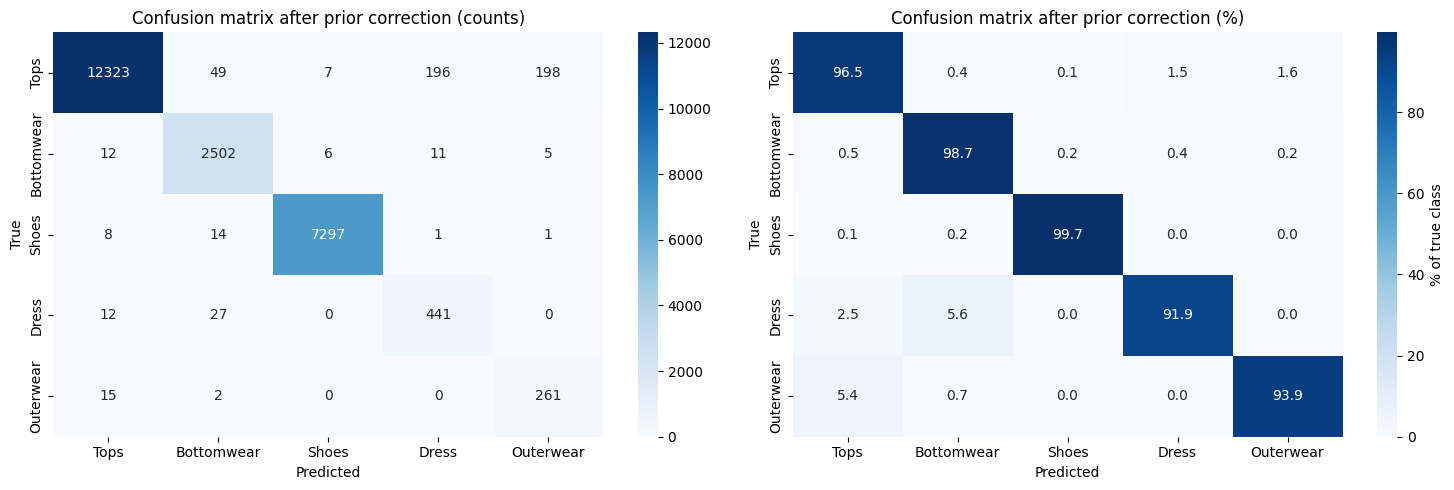

              precision    recall  f1-score   support

        Tops     0.9962    0.9648    0.9802     12773
  Bottomwear     0.9645    0.9866    0.9754      2536
       Shoes     0.9982    0.9967    0.9975      7321
       Dress     0.6795    0.9187    0.7812       480
   Outerwear     0.5613    0.9388    0.7026       278

    accuracy                         0.9759     23388
   macro avg     0.8400    0.9611    0.8874     23388
weighted avg     0.9817    0.9759    0.9777     23388



In [10]:
cm_c     = confusion_matrix(all_labels, corrected_preds)
cm_c_pct = cm_c / cm_c.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm_c, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion matrix after prior correction (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_c_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
            cbar_kws={"label": "% of true class"})
axes[1].set_title("Confusion matrix after prior correction (%)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout(); plt.show()

print(classification_report(all_labels, corrected_preds, target_names=CLASS_NAMES, digits=4))